In [1]:
STUDENT_NAME = "Lê Thái Đức Tùng"
STUDENT_ID = "ITDSIU24055"
CLASS_GROUP = "IT171IU - Lab Group 01"
print(f"Lab 2 | {STUDENT_NAME} | {STUDENT_ID} | {CLASS_GROUP}")

Lab 2 | Lê Thái Đức Tùng | ITDSIU24055 | IT171IU - Lab Group 01


In [2]:
# [ADDED]
# 0. Setup – run this cell first (installs missing packages and fetches data files).
# On Google Colab the first run takes about 1 minute. If Colab asks you to
# "Restart session", accept, then run this cell once more.
import sys, os, subprocess, importlib.util, urllib.request

def ensure(module, pip_name=None):
    """pip-install a package only if it cannot be imported yet."""
    if importlib.util.find_spec(module) is None:
        print(f"Installing {pip_name or module} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name or module], check=True)

ensure("ISLP", "ISLP")

print("Setup complete – Python", sys.version.split()[0])

Setup complete – Python 3.12.10


In [3]:
# [ADDED] helper for the additional datasets
# Loader for the additional datasets of this course (folder "additional-data/").
# If the CSV file is not found next to the notebook, it is rebuilt from its public source,
# so the notebook also works on Colab without uploading anything.
import pandas as pd
def load_extra(name):
    for folder in ["additional-data", "../additional-data", "/content/additional-data",
                   "/content/drive/MyDrive/additional-data"]:
        path = os.path.join(folder, name + ".csv")
        if os.path.exists(path):
            return pd.read_csv(path)
    from sklearn import datasets as skd
    if name == "diabetes":
        d = skd.load_diabetes(as_frame=True, scaled=False); df = d.frame.rename(columns={"target": "progression"})
    elif name == "breast_cancer":
        d = skd.load_breast_cancer(as_frame=True); df = d.frame.copy()
        df["diagnosis"] = pd.Categorical.from_codes(d.target, ["malignant", "benign"]); df = df.drop(columns="target")
    elif name == "wine":
        d = skd.load_wine(as_frame=True); df = d.frame.rename(columns={"target": "cultivar"})
    elif name == "digits":
        d = skd.load_digits(as_frame=True); df = d.frame.rename(columns={"target": "digit"})
    elif name == "rossi":
        from lifelines.datasets import load_rossi; df = load_rossi()
    else:
        raise ValueError(f"unknown dataset {name!r}")
    return df

In [4]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [5]:
import statsmodels.api as sm

In [6]:
from statsmodels.stats.outliers_influence \
     import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [7]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

In [8]:
import pandas as pd

Boston : pd.DataFrame = load_data("Boston")
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [9]:
X = pd.DataFrame({'intercept': np.ones(Boston.shape[0]),
                  'lstat': Boston['lstat']})
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [10]:
y = Boston['medv']
model = sm.OLS(y, X)
results = model.fit()

summarize(results)

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


In [11]:
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


# <span style="color:red">4. Exercises</span>

<span style="color:red">For every exercise write **code + output + a short interpretation**. Exercises 1–7 are compulsory; 8–9 are challenge (bonus) exercises. Use `load_data()` for the ISLP data sets and `load_extra()` (defined in the Setup section) for the additional data sets.</span>

## <span style="color:red">Exercise 1 – Simple regression on `Auto`</span>

- <span style="color:red">**(a)** Fit `mpg` on `horsepower` with `sm.OLS` and print the summary.</span>
- <span style="color:red">**(b)** Is there a relationship between the predictor and the response? How strong is it ($R^2$, RSE)? Is it positive or negative?</span>
- <span style="color:red">**(c)** What is the predicted `mpg` for `horsepower = 98`? Give the 95% **confidence** and **prediction** intervals.</span>
- <span style="color:red">**(d)** Plot `mpg` against `horsepower` with the least-squares line (use the `abline()` function of the lab) and draw the residual plot. Comment on any problems.</span>

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

from typing import cast
from ISLP import load_data
from ISLP.models import ModelSpec as MS
from ISLP.models import summarize


def design_matrix(terms, data) -> pd.DataFrame:
    """MS(...).fit_transform() thực tế trả về DataFrame, nhưng stub sklearn của
    Pylance khai báo TransformerMixin.fit_transform -> ndarray, nên .columns /
    .values bị gạch đỏ oan. Bọc lại một lần để Pylance báo đúng kiểu."""
    return cast(pd.DataFrame, MS(terms).fit_transform(data))

In [13]:
# ✍️ Exercise 1 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
Auto: pd.DataFrame = load_data('Auto')
design_hp = MS(['horsepower'])
X_hp = design_hp.fit_transform(Auto)
fit_hp = sm.OLS(Auto['mpg'], X_hp).fit()                   # TODO (a): sm.OLS(Auto['mpg'], X_hp).fit()

In [14]:
# (b)
# In these variables below what is predictor and what is response
# -> Predictor is X and Response is mpg
# Connection between them is fit_hp
# Relationship between them -> strong or not && positive or negative

summarize(fit_hp)

,coef,std err,t,P>|t|
intercept,39.9359,0.717,55.660,0.0
horsepower,-0.1578,0.006,-24.489,0.0


In [15]:
# What is R^2 or RSE?
print("R^2:", fit_hp.rsquared)
print("RSE:", np.sqrt(fit_hp.mse_resid))

R^2: 0.6059482578894348
RSE: 4.90575691954594


In [16]:
print(fit_hp)

In [17]:
# TODO (c): pred = fit_hp.get_prediction(design_hp.transform(new)); pred.conf_int(alpha=0.05); pred.conf_int(obs=True, alpha=0.05)
# What is the predicted "mpg" for "horsepower = 98"
new = pd.DataFrame({'horsepower': [98]})
newX = design_hp.transform(new)
pred = fit_hp.get_prediction(newX)

print("Confidence interval:", pred.conf_int(alpha=0.05))
print("Prediction interval:", pred.conf_int(obs=True, alpha=0.05))

Confidence interval: [[23.97307896 24.96107534]]
Prediction interval: [[14.80939607 34.12475823]]


In [18]:
# TODO (d): plots

In [19]:
def abline(ax, b, m):
    "Add a line with slope m and intercept b to ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim)

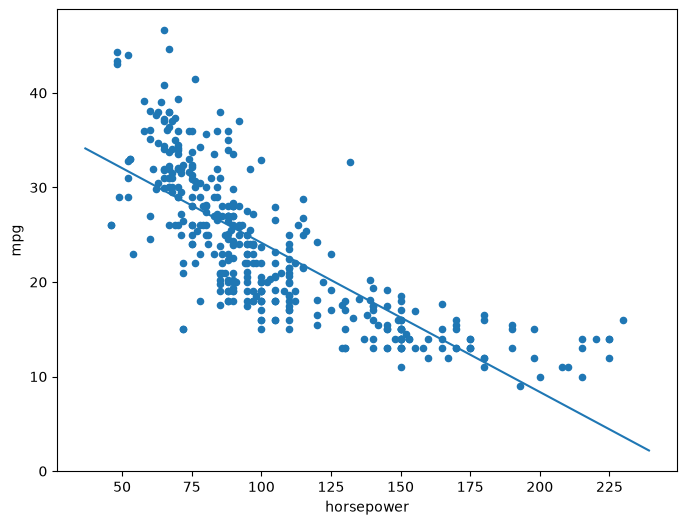

In [20]:
# What are the least-square line and the residual plot
# least-square is just one type of line in linear regression
# by OLS
# m is slope, b is y-intercept, ax?

import matplotlib.pyplot as plt

ax = Auto.plot.scatter("horsepower", "mpg", figsize=(8, 6))
b = fit_hp.params['intercept']
m = fit_hp.params['horsepower']

abline(ax, b, m)


Text(0, 0.5, 'Residual')

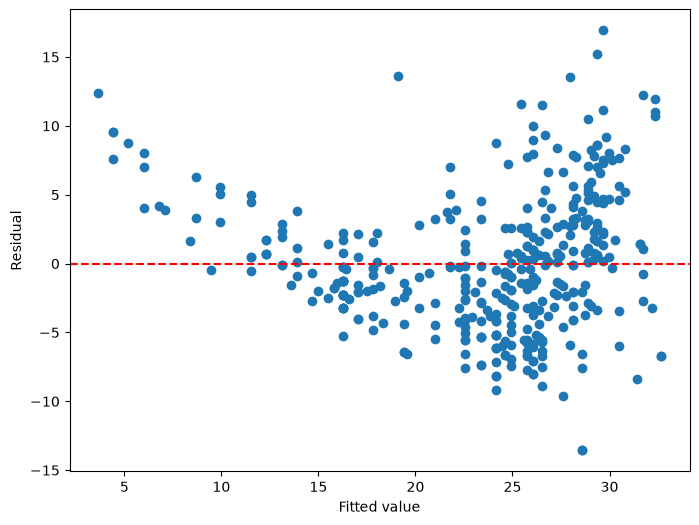

In [21]:
fig, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(fit_hp.fittedvalues, fit_hp.resid)
ax2.axhline(0, color='r', linestyle='--')
ax2.set_xlabel("Fitted value")
ax2.set_ylabel("Residual")

## <span style="color:red">Exercise 2 – Multiple regression on `Auto`</span>

- <span style="color:red">**(a)** Produce the correlation matrix of the quantitative variables (exclude `name`).</span>
- <span style="color:red">**(b)** Fit `mpg` on **all** other variables except `name`. Which predictors are significant? What does the coefficient of `year` suggest?</span>
- <span style="color:red">**(c)** Draw the residual plot and the leverage plot. Are there unusually large outliers or high-leverage points?</span>
- <span style="color:red">**(d)** Compute the VIF of each predictor. Which ones indicate collinearity?</span>

In [22]:
# ✍️ Exercise 2 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
Auto_num = Auto.drop(columns=['name']) if 'name' in Auto.columns else Auto.copy()
print(Auto_num.corr().round(2))

               mpg  cylinders  displacement  horsepower  weight  acceleration  \
mpg           1.00      -0.78         -0.81       -0.78   -0.83          0.42   
cylinders    -0.78       1.00          0.95        0.84    0.90         -0.50   
displacement -0.81       0.95          1.00        0.90    0.93         -0.54   
horsepower   -0.78       0.84          0.90        1.00    0.86         -0.69   
weight       -0.83       0.90          0.93        0.86    1.00         -0.42   
acceleration  0.42      -0.50         -0.54       -0.69   -0.42          1.00   
year          0.58      -0.35         -0.37       -0.42   -0.31          0.29   
origin        0.57      -0.57         -0.61       -0.46   -0.59          0.21   

              year  origin  
mpg           0.58    0.57  
cylinders    -0.35   -0.57  
displacement -0.37   -0.61  
horsepower   -0.42   -0.46  
weight       -0.31   -0.59  
acceleration  0.29    0.21  
year          1.00    0.18  
origin        0.18    1.00  


In [ ]:
# (b)
terms = Auto_num.columns.drop('mpg')
X_all = design_matrix(terms, Auto_num)
fit_all = sm.OLS(Auto_num['mpg'], X_all).fit()                  # TODO (b)
# What is the significant predictor?
summarize(fit_all)[summarize(fit_all)["P>|t|"] < 0.05]

In [24]:
year_coef = summarize(fit_all).loc["year", "coef"]
print("Coefficient of year:", year_coef)
# What does "suggest" mean?
# It just the predicted variable or anything else?
print("Xe sản xuất sau 1 năm sẽ tiết kiệm nhiên liệu hơn khoảng 0.75 mpg")

Coefficient of year: 0.7508
Xe sản xuất sau 1 năm sẽ tiết kiệm nhiên liệu hơn khoảng 0.75 mpg


Text(0, 0.5, 'Studentized residual')

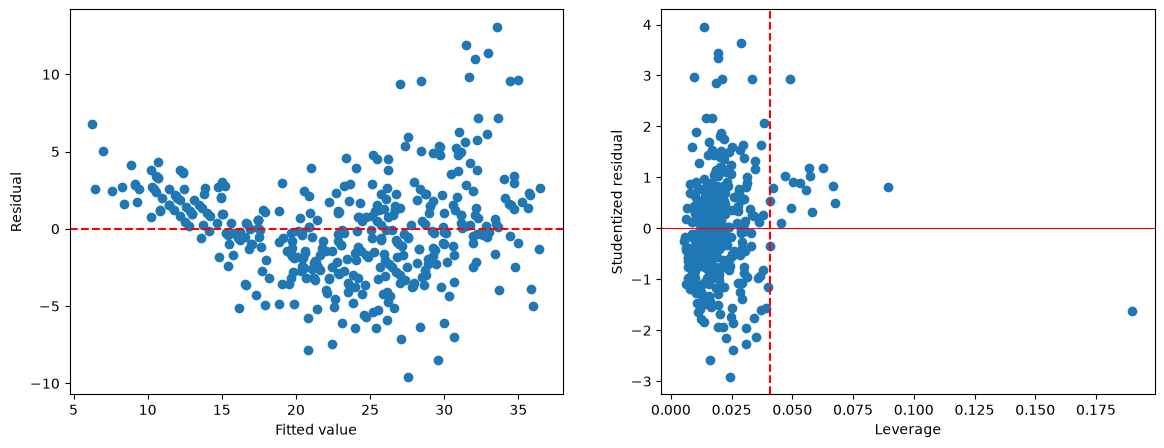

In [25]:
# TODO (c), (d): use fit_all.get_influence() and VIF(X_all, i)
infl = fit_all.get_influence()
n, p = X_all.shape

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.scatter(fit_all.fittedvalues, fit_all.resid)
ax1.axhline(0, color='r', linestyle='--')
ax1.set_xlabel("Fitted value"); ax1.set_ylabel("Residual")

ax2.scatter(infl.hat_matrix_diag, infl.resid_studentized_internal)
ax2.axvline(2 * p / n, color="r", linestyle="--", label=f"2p/n = {2*p/n:.3f}")
ax2.axhline(0, color="r", linewidth=0.8)
ax2.set_xlabel("Leverage"); ax2.set_ylabel("Studentized residual")

In [ ]:
vals = [VIF(X_all, i) for i in range(1, X_all.shape[1])]
vif = pd.DataFrame({'VIF': vals}, index=X_all.columns[1:])
print(vif.round(2).sort_values("VIF", ascending=False))

## <span style="color:red">Exercise 3 – Interactions and transformations</span>

<span style="color:red">Starting from Exercise 2, try **at least three** of the following and report $R^2$, the significance of the new terms and an `anova_lm()` comparison with the model without them:</span>

- <span style="color:red">an interaction such as `('horsepower', 'weight')` or `('displacement', 'year')`;</span>
- <span style="color:red">`poly('horsepower', degree=2)`;</span>
- <span style="color:red">$\log(\text{horsepower})$, $\sqrt{\text{horsepower}}$ or $\text{horsepower}^2$ (create new columns first).</span>

<span style="color:red">Which model would you choose and why?</span>

In [ ]:
# ✍️ Exercise 3 – your code
# Write your code below (replace the TODOs), then run the cell (Shift+Enter).
Auto_num['log_hp'] = np.log(Auto_num['horsepower'])
base = sm.OLS(Auto_num['mpg'], MS(['weight', 'year', 'horsepower']).fit_transform(Auto_num)).fit()
# TODO: inter = sm.OLS(Auto_num['mpg'], MS(['weight', 'year', 'horsepower', ('horsepower', 'weight')]).fit_transform(Auto_num)).fit()
# TODO: print(anova_lm(base, inter))